# Test Suite Notebook

Bottom-up order:
1. Basic utilities
2. Determinants
3. QR helpers
4. QR / shifted QR
5. Power/deflation and diagonalization helpers
6. Full diagonalization
7. SVD helpers and full SVD
8. Benchmarks (all at the end)

Matrix convention: for A in R^(m x n), each row is a vector in R^n.


## 1) Import Dependencies


In [1]:
import time
import random
import math
import numpy as np
import matplotlib.pyplot as plt

from utils import (
    transpose,
    matrix_multiply,
    matrix_add,
    matrix_subtract,
    scalar_multiply_matrix,
    identity_matrix,
    normalize,
    shape,
    laplace_get_determinant,
    gauss_get_determinant,
)

from QR import (
    _dot,
    project,
    gram_schmidt,
    qr_decomposition,
    makesimilar,
    eig_qr,
    eig_qrshift,
)

import diagonalization as diag
from diagonalization import (
    power_iteration,
    deflation,
    solve_rref,
    eigenvector_from_lambda,
    diagonalize,
)

import SVD as svd_mod
from SVD import svd_decomposition

np.set_printoptions(precision=6, suppress=True)


## 2) Implemented Methods


In [2]:
implemented_methods = {
    "determinant_methods": ["laplace_get_determinant", "gauss_get_determinant"],
    "eigenvalue_methods": ["qr_shift", "qr", "power_method"],
    "eigenvector_methods": ["inverse_iteration", "power_method", "eigenvector_from_lambda"],
    "svd_interface": ["svd_decomposition(A, eigenvalue_method=..., eigenvector_method=...)"],
}

for group, methods in implemented_methods.items():
    print(group + ":")
    for method in methods:
        print("  -", method)


determinant_methods:
  - laplace_get_determinant
  - gauss_get_determinant
eigenvalue_methods:
  - qr_shift
  - qr
  - power_method
eigenvector_methods:
  - inverse_iteration
  - power_method
  - eigenvector_from_lambda
svd_interface:
  - svd_decomposition(A, eigenvalue_method=..., eigenvector_method=...)


## 3) Test Helpers


In [3]:
def to_np(A):
    return np.array(A, dtype=float)


def fmt_matrix(M):
    return np.array(M, dtype=float)


def assert_close(actual, expected, atol=1e-6, msg=''):
    a = np.array(actual, dtype=float)
    b = np.array(expected, dtype=float)
    if not np.allclose(a, b, atol=atol, rtol=0):
        raise AssertionError(f"{msg}\nactual={a}\nexpected={b}")


def assert_true(cond, msg='assert_true failed'):
    if not cond:
        raise AssertionError(msg)


def run_test(stats, name, fn, detail=True):
    stats['total'] += 1
    try:
        note = fn()
        stats['passed'] += 1
        print(f"[PASS]: {name}")
        if detail and note:
            print(note)
        print('_______________\n')
    except Exception as exc:
        print(f"[FAIL]: {name} -> {exc}")
        print('_______________\n')


def report(section, stats):
    print(f"[{section}] {stats['passed']}/{stats['total']} tests passed")


def generate_symmetric_matrix(n, seed=42):
    random.seed(seed)
    A = [[random.uniform(-1, 1) for _ in range(n)] for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            x = 0.5 * (A[i][j] + A[j][i])
            A[i][j] = x
            A[j][i] = x
    return A


def generate_random_matrix(m, n, seed=42):
    random.seed(seed)
    return [[random.uniform(-2, 2) for _ in range(n)] for _ in range(m)]


def reconstruction_error(A, U, Sigma, V):
    A_hat = matrix_multiply(matrix_multiply(U, Sigma), transpose(V))
    err = 0.0
    for i in range(len(A)):
        for j in range(len(A[0])):
            err += (A[i][j] - A_hat[i][j]) ** 2
    return math.sqrt(err)


def align_qr_to_numpy(Q, R, Q_ref):
    Q_np = to_np(Q)
    R_np = to_np(R)
    Q_ref_np = to_np(Q_ref)
    signs = np.sign(np.diag(Q_np.T @ Q_ref_np))
    signs[signs == 0] = 1.0
    D = np.diag(signs)
    return Q_np @ D, D @ R_np


def svd_reconstruction_from_numpy(A):
    U, s, Vt = np.linalg.svd(to_np(A), full_matrices=True)
    Sigma = np.zeros((U.shape[0], Vt.shape[0]))
    for i, value in enumerate(s):
        Sigma[i, i] = value
    return U, Sigma, Vt.T


## 4) Basic Matrix Utility Tests


In [4]:
def test_basic_utilities():
    stats = {'passed': 0, 'total': 0}

    def t_transpose():
        A = [[1, 2, 3], [4, 5, 6]]
        out = transpose(A)
        exp = [[1, 4], [2, 5], [3, 6]]
        assert_close(out, exp, msg='transpose mismatch')
        np_out = np.transpose(A)
        np_error = np.linalg.norm(to_np(out) - np_out)
        return f"A=\n{fmt_matrix(A)}\ntranspose(A)=\n{fmt_matrix(out)}\nNumPy transpose=\n{np_out}\n||transpose-NumPy||_F={np_error:.3e}"
    run_test(stats, 'transpose', t_transpose)

    def t_shape():
        A = [[1, 2], [3, 4], [5, 6]]
        out = shape(A)
        exp = (3, 2)
        assert_close(out, exp, msg='shape mismatch')
        np_shape = np.shape(A)
        return f"A=\n{fmt_matrix(A)}\nshape(A)={out}, expected={exp}, NumPy shape={np_shape}"
    run_test(stats, 'shape', t_shape)

    def t_multiply():
        A = [[1, 2], [3, 4]]
        B = [[5, 6], [7, 8]]
        out = matrix_multiply(A, B)
        exp = [[19, 22], [43, 50]]
        assert_close(out, exp, msg='matrix_multiply mismatch')
        np_out = np.matmul(to_np(A), to_np(B))
        np_error = np.linalg.norm(to_np(out) - np_out)
        return f"A=\n{fmt_matrix(A)}\nB=\n{fmt_matrix(B)}\nA*B=\n{fmt_matrix(out)}\nNumPy A@B=\n{np_out}\n||A*B-NumPy||_F={np_error:.3e}"
    run_test(stats, 'matrix_multiply', t_multiply)

    def t_add_subtract():
        A = [[1, 2], [3, 4]]
        B = [[4, 3], [2, 1]]
        out_add = matrix_add(A, B)
        out_sub = matrix_subtract(out_add, B)
        assert_close(out_add, [[5, 5], [5, 5]], msg='matrix_add mismatch')
        assert_close(out_sub, A, msg='matrix_subtract mismatch')
        np_add = np.array(A) + np.array(B)
        np_sub = np_add - np.array(B)
        add_error = np.linalg.norm(to_np(out_add) - np_add)
        sub_error = np.linalg.norm(to_np(out_sub) - np_sub)
        return f"A=\n{fmt_matrix(A)}\nB=\n{fmt_matrix(B)}\nA+B=\n{fmt_matrix(out_add)}\nNumPy A+B=\n{np_add}\n||A+B-NumPy||_F={add_error:.3e}\n(A+B)-B=\n{fmt_matrix(out_sub)}\nNumPy back-subtract=\n{np_sub}\n||sub-NumPy||_F={sub_error:.3e}"
    run_test(stats, 'matrix_add/subtract', t_add_subtract)

    def t_scalar_mul():
        A = [[1, -2], [3, 0]]
        out = scalar_multiply_matrix(A, 2.5)
        exp = [[2.5, -5.0], [7.5, 0.0]]
        assert_close(out, exp, msg='scalar_multiply mismatch')
        np_out = np.array(A) * 2.5
        np_error = np.linalg.norm(to_np(out) - np_out)
        return f"A=\n{fmt_matrix(A)}\nscalar=2.5\n2.5*A=\n{fmt_matrix(out)}\nNumPy 2.5*A=\n{np_out}\n||2.5*A-NumPy||_F={np_error:.3e}"
    run_test(stats, 'scalar_multiply_matrix', t_scalar_mul)

    def t_identity():
        out = identity_matrix(3)
        exp = np.eye(3)
        assert_close(out, exp, msg='identity_matrix mismatch')
        np_error = np.linalg.norm(to_np(out) - np.eye(3))
        return f"n=3\nI3=\n{fmt_matrix(out)}\nNumPy eye(3)=\n{np.eye(3)}\n||I3-NumPy||_F={np_error:.3e}"
    run_test(stats, 'identity_matrix', t_identity)

    def t_normalize():
        v = [3.0, 4.0]
        out = normalize(v)
        assert_close(np.linalg.norm(out), 1.0, atol=1e-8, msg='normalize norm != 1')
        np_out = (np.array(v) / np.linalg.norm(v)).tolist()
        np_error = np.linalg.norm(to_np(out) - np.array(np_out))
        return f"v={v}\nnormalize(v)={out}\nNumPy normalized={np_out}\n||normalize-NumPy||_F={np_error:.3e}\nnorm={np.linalg.norm(out):.6f}"
    run_test(stats, 'normalize', t_normalize)

    def t_dot():
        u = [1, 2, 3]
        v = [4, 5, 6]
        out = _dot(u, v)
        assert_close(out, 32.0, msg='dot mismatch')
        np_out = np.dot(u, v)
        return f"u={u}\nv={v}\nu.v={out}\nNumPy dot={np_out}\n||dot-NumPy||={abs(out - np_out):.3e}"
    run_test(stats, '_dot', t_dot)

    def t_project():
        u = [2.0, -1.0, 3.0]
        v = [1.0, 2.0, 2.0]
        out = project(u, v)
        exp = (((to_np(u) @ to_np(v)) / (to_np(v) @ to_np(v))) * to_np(v)).tolist()
        assert_close(out, exp, atol=1e-8, msg='project mismatch')
        np_proj = (((to_np(u) @ to_np(v)) / (to_np(v) @ to_np(v))) * to_np(v))
        np_error = np.linalg.norm(to_np(out) - np_proj)
        return f"u={u}\nv={v}\nproj_v(u)={out}\nNumPy projection={np_proj}\n||proj-NumPy||_F={np_error:.3e}"
    run_test(stats, 'project', t_project)

    report('Section 4', stats)
    return stats

_ = test_basic_utilities()


[PASS]: transpose
A=
[[1. 2. 3.]
 [4. 5. 6.]]
transpose(A)=
[[1. 4.]
 [2. 5.]
 [3. 6.]]
NumPy transpose=
[[1 4]
 [2 5]
 [3 6]]
||transpose-NumPy||_F=0.000e+00
_______________

[PASS]: shape
A=
[[1. 2.]
 [3. 4.]
 [5. 6.]]
shape(A)=(3, 2), expected=(3, 2), NumPy shape=(3, 2)
_______________

[PASS]: matrix_multiply
A=
[[1. 2.]
 [3. 4.]]
B=
[[5. 6.]
 [7. 8.]]
A*B=
[[19. 22.]
 [43. 50.]]
NumPy A@B=
[[19. 22.]
 [43. 50.]]
||A*B-NumPy||_F=0.000e+00
_______________

[PASS]: matrix_add/subtract
A=
[[1. 2.]
 [3. 4.]]
B=
[[4. 3.]
 [2. 1.]]
A+B=
[[5. 5.]
 [5. 5.]]
NumPy A+B=
[[5 5]
 [5 5]]
||A+B-NumPy||_F=0.000e+00
(A+B)-B=
[[1. 2.]
 [3. 4.]]
NumPy back-subtract=
[[1 2]
 [3 4]]
||sub-NumPy||_F=0.000e+00
_______________

[PASS]: scalar_multiply_matrix
A=
[[ 1. -2.]
 [ 3.  0.]]
scalar=2.5
2.5*A=
[[ 2.5 -5. ]
 [ 7.5  0. ]]
NumPy 2.5*A=
[[ 2.5 -5. ]
 [ 7.5  0. ]]
||2.5*A-NumPy||_F=0.000e+00
_______________

[PASS]: identity_matrix
n=3
I3=
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
NumPy eye(3)=
[[1. 0. 0.]

## 5) Determinant Tests


In [5]:
def test_determinant_methods():
    stats = {'passed': 0, 'total': 0}

    def t_2x2():
        A = [[4, 7], [2, 6]]
        l = laplace_get_determinant(A)
        g = gauss_get_determinant(A)
        assert_close(l, 10.0, msg='laplace 2x2 mismatch')
        assert_close(g, 10.0, msg='gauss 2x2 mismatch')
        np_det = np.linalg.det(to_np(A))
        return f"A=\n{fmt_matrix(A)}\nLaplace={l}, Gauss={g}\nNumPy det={np_det:.6f}\n||Laplace-NumPy||={abs(l - np_det):.3e}\n||Gauss-NumPy||={abs(g - np_det):.3e}"
    run_test(stats, 'determinant 2x2', t_2x2)

    def t_3x3():
        A = [[1, 2, 3], [0, 4, 5], [1, 0, 6]]
        l = laplace_get_determinant(A)
        g = gauss_get_determinant(A)
        assert_close(l, 22.0, msg='laplace 3x3 mismatch')
        assert_close(g, 22.0, msg='gauss 3x3 mismatch')
        np_det = np.linalg.det(to_np(A))
        return f"A=\n{fmt_matrix(A)}\nLaplace={l}, Gauss={g}\nNumPy det={np_det:.6f}\n||Laplace-NumPy||={abs(l - np_det):.3e}\n||Gauss-NumPy||={abs(g - np_det):.3e}"
    run_test(stats, 'determinant 3x3', t_3x3)

    def t_singular():
        A = [[1, 2], [2, 4]]
        l = laplace_get_determinant(A)
        g = gauss_get_determinant(A)
        assert_close(l, 0.0, msg='laplace singular mismatch')
        assert_close(g, 0.0, msg='gauss singular mismatch')
        np_det = np.linalg.det(to_np(A))
        return f"A=\n{fmt_matrix(A)}\nLaplace={l}, Gauss={g}\nNumPy det={np_det:.6f}\n||Laplace-NumPy||={abs(l - np_det):.3e}\n||Gauss-NumPy||={abs(g - np_det):.3e}"
    run_test(stats, 'determinant singular matrix', t_singular)

    def t_random_agreement():
        A = [[2, -1, 0], [1, 3, 4], [5, 2, 1]]
        l = laplace_get_determinant(A)
        g = gauss_get_determinant(A)
        assert_close(l, g, atol=1e-8, msg='laplace vs gauss disagreement')
        np_det = np.linalg.det(to_np(A))
        return f"A=\n{fmt_matrix(A)}\nLaplace={l}, Gauss={g}\nNumPy det={np_det:.6f}\n||Laplace-NumPy||={abs(l - np_det):.3e}\n||Gauss-NumPy||={abs(g - np_det):.3e}"
    run_test(stats, 'laplace vs gauss agreement', t_random_agreement)

    report('Section 5', stats)
    return stats

_ = test_determinant_methods()


[PASS]: determinant 2x2
A=
[[4. 7.]
 [2. 6.]]
Laplace=10, Gauss=10.0
NumPy det=10.000000
||Laplace-NumPy||=1.776e-15
||Gauss-NumPy||=1.776e-15
_______________

[PASS]: determinant 3x3
A=
[[1. 2. 3.]
 [0. 4. 5.]
 [1. 0. 6.]]
Laplace=22, Gauss=22.0
NumPy det=22.000000
||Laplace-NumPy||=3.553e-15
||Gauss-NumPy||=3.553e-15
_______________

[PASS]: determinant singular matrix
A=
[[1. 2.]
 [2. 4.]]
Laplace=0, Gauss=0
NumPy det=0.000000
||Laplace-NumPy||=0.000e+00
||Gauss-NumPy||=0.000e+00
_______________

[PASS]: laplace vs gauss agreement
A=
[[ 2. -1.  0.]
 [ 1.  3.  4.]
 [ 5.  2.  1.]]
Laplace=-29, Gauss=-29.000000000000004
NumPy det=-29.000000
||Laplace-NumPy||=1.066e-14
||Gauss-NumPy||=1.421e-14
_______________

[Section 5] 4/4 tests passed


## 6) QR Helper and QR Core Tests


In [6]:
def test_qr_all():
    stats = {'passed': 0, 'total': 0}

    A = [[4.0, 1.0, 0.0], [1.0, 3.0, 1.0], [0.0, 1.0, 2.0]]
    A_np = to_np(A)

    def t_gram_schmidt():
        Q = gram_schmidt(A)
        assert_close(to_np(Q).T @ to_np(Q), np.eye(3), atol=1e-5, msg='Q^TQ != I')
        return f"A=\n{fmt_matrix(A)}\nQ=\n{fmt_matrix(Q)}"
    run_test(stats, 'gram_schmidt orthonormal columns', t_gram_schmidt)

    def t_qr_reconstruct():
        Q, R = qr_decomposition(A)
        recon = to_np(Q) @ to_np(R)
        assert_close(recon, A_np, atol=1e-5, msg='A != QR')
        return f"A=\n{fmt_matrix(A)}\nQ=\n{fmt_matrix(Q)}\nR=\n{fmt_matrix(R)}"
    run_test(stats, 'qr_decomposition reconstructs A', t_qr_reconstruct)

    def t_R_upper():
        _, R = qr_decomposition(A)
        assert_close(np.tril(to_np(R), -1), np.zeros((3, 3)), atol=1e-6, msg='R not upper')
        return f"A=\n{fmt_matrix(A)}\nR lower part=\n{np.tril(to_np(R), -1)}"
    run_test(stats, 'R upper triangular', t_R_upper)

    def t_makesimilar():
        Q, R = qr_decomposition(A)
        B = makesimilar(A)
        assert_close(to_np(B), to_np(R) @ to_np(Q), atol=1e-6, msg='makesimilar mismatch')
        return f"A=\n{fmt_matrix(A)}\nB=R@Q=\n{fmt_matrix(B)}"
    run_test(stats, 'makesimilar = RQ', t_makesimilar)

    def t_eig_qr():
        vals, it = eig_qr(A)
        exp = np.linalg.eigvals(A_np).real.tolist()
        assert_close(sorted(vals), sorted(exp), atol=1e-3, msg='eig_qr mismatch')
        return f"A=\n{fmt_matrix(A)}\neig_qr vals={sorted(vals)}\nnumpy vals={sorted(exp)}\niterations={it}"
    run_test(stats, 'eig_qr eigenvalues', t_eig_qr)

    def t_eig_qrshift():
        A_shift = [[6.0, 2.0, 1.0], [2.0, 5.0, 2.0], [1.0, 2.0, 4.0]]
        vals, it = eig_qrshift(A_shift)
        exp = np.linalg.eigvals(to_np(A_shift)).real.tolist()
        assert_close(sorted(vals), sorted(exp), atol=1e-3, msg='eig_qrshift mismatch')
        return f"A_shift=\n{fmt_matrix(A_shift)}\neig_qrshift vals={sorted(vals)}\nnumpy vals={sorted(exp)}\niterations={it}"
    run_test(stats, 'eig_qrshift eigenvalues', t_eig_qrshift)

    def t_qr_numpy_compare():
        Q, R = qr_decomposition(A)
        Q_ref, R_ref = np.linalg.qr(A_np)
        Q_adj, R_adj = align_qr_to_numpy(Q, R, Q_ref)
        assert_close(Q_adj, Q_ref, atol=1e-5, msg='Q does not match numpy.linalg.qr after sign alignment')
        assert_close(R_adj, R_ref, atol=1e-5, msg='R does not match numpy.linalg.qr after sign alignment')
        assert_close(Q_adj @ R_adj, A_np, atol=1e-5, msg='QR reconstruction mismatch against numpy')
        q_error = np.linalg.norm(Q_adj - Q_ref)
        r_error = np.linalg.norm(R_adj - R_ref)
        recon_error = np.linalg.norm(Q_adj @ R_adj - A_np)
        return f"A=\n{fmt_matrix(A)}\nNumPy Q=\n{Q_ref}\nOur Q aligned=\n{Q_adj}\n||Q-Q_numpy||_F={q_error:.3e}\nNumPy R=\n{R_ref}\nOur R aligned=\n{R_adj}\n||R-R_numpy||_F={r_error:.3e}\n||QR-A||_F={recon_error:.3e}"
    run_test(stats, 'qr_decomposition vs numpy.linalg.qr', t_qr_numpy_compare)

    def t_qr_small_matrix():
        B = [[2.0, -1.0], [1.0, 3.0]]
        Q, R = qr_decomposition(B)
        Q_ref, R_ref = np.linalg.qr(to_np(B))
        Q_adj, R_adj = align_qr_to_numpy(Q, R, Q_ref)
        assert_close(Q_adj, Q_ref, atol=1e-5, msg='2x2 Q mismatch vs numpy')
        assert_close(R_adj, R_ref, atol=1e-5, msg='2x2 R mismatch vs numpy')
        q_error = np.linalg.norm(Q_adj - Q_ref)
        r_error = np.linalg.norm(R_adj - R_ref)
        recon_error = np.linalg.norm(Q_adj @ R_adj - to_np(B))
        return f"B=\n{fmt_matrix(B)}\nQ=\n{Q_adj}\n||Q-Q_numpy||_F={q_error:.3e}\nR=\n{R_adj}\n||R-R_numpy||_F={r_error:.3e}\n||QR-B||_F={recon_error:.3e}"
    run_test(stats, 'qr_decomposition 2x2 numpy check', t_qr_small_matrix)

    report('Section 6', stats)
    return stats

_ = test_qr_all()


[PASS]: gram_schmidt orthonormal columns
A=
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
Q=
[[ 0.970143 -0.227106  0.085126]
 [ 0.242536  0.908424 -0.340503]
 [ 0.        0.350982  0.936382]]
_______________

[PASS]: qr_decomposition reconstructs A
A=
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
Q=
[[ 0.970143 -0.227106  0.085126]
 [ 0.242536  0.908424 -0.340503]
 [ 0.        0.350982  0.936382]]
R=
[[4.123106 1.697749 0.242536]
 [0.       2.849148 1.610388]
 [0.       0.       1.532262]]
_______________

[PASS]: R upper triangular
A=
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
R lower part=
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
_______________

[PASS]: makesimilar = RQ
A=
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
B=R@Q=
[[4.411765 0.69102  0.      ]
 [0.69102  3.153453 0.537796]
 [0.       0.537796 1.434783]]
_______________

[PASS]: eig_qr eigenvalues
A=
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
eig_qr vals=[1.2679491924367086, 3.000001071016632, 4.732049736546659]
numpy vals=[1.2679491924311228, 3.0000000000000013, 

## 7) Power/Deflation and Diagonalization Helper Tests


In [7]:
def test_diagonalization_helpers():
    stats = {'passed': 0, 'total': 0}

    A = [[5.0, 2.0, 0.0], [2.0, 3.0, 0.0], [0.0, 0.0, 1.0]]
    A_np = to_np(A)

    def t_power():
        lam, v = power_iteration(A)
        res = np.linalg.norm(A_np @ to_np(v) - lam * to_np(v))
        assert_true(res < 5e-3, f'power residual too large: {res}')
        evals = np.linalg.eigvals(A_np).real
        lam_np = float(np.max(evals))
        return f"A=\n{fmt_matrix(A)}\nlambda={lam:.6f}\nNumPy largest eigenvalue={lam_np:.6f}\n|lambda-NumPy|={abs(lam - lam_np):.3e}\nv={np.array(v)}\nresidual={res:.3e}"
    run_test(stats, 'power_iteration residual', t_power)

    def t_deflation_shape():
        lam, v = power_iteration(A)
        A2 = deflation(A, lam, v)
        assert_true(shape(A2) == shape(A), 'deflation shape mismatch')
        return f"A=\n{fmt_matrix(A)}\nshape(A)={shape(A)}, shape(deflated)={shape(A2)}"
    run_test(stats, 'deflation keeps shape', t_deflation_shape)

    def t_rref():
        M = [[1.0, 2.0, 3.0], [2.0, 4.0, 6.0], [0.0, 1.0, 1.0]]
        E, piv = solve_rref([row[:] for row in M])
        assert_true(len(piv) >= 2, 'pivot detection failed')
        return f"M=\n{fmt_matrix(M)}\nEchelon=\n{fmt_matrix(E)}\npivots={piv}"
    run_test(stats, 'solve_rref pivot detection', t_rref)

    lam_max = max(np.linalg.eigvals(A_np).real.tolist())

    def t_evec_from_lambda():
        v = eigenvector_from_lambda(A, lam_max)
        res = np.linalg.norm((A_np - lam_max * np.eye(3)) @ to_np(v))
        assert_true(res < 5e-3, f'eigenvector_from_lambda residual too large: {res}')
        evals = np.linalg.eigvals(A_np).real
        lam_np = float(np.max(evals))
        return f"A=\n{fmt_matrix(A)}\nlambda={lam_max:.6f}\nNumPy largest eigenvalue={lam_np:.6f}\n|lambda-NumPy|={abs(lam_max - lam_np):.3e}\nv={np.array(v)}\nresidual={res:.3e}"
    run_test(stats, 'eigenvector_from_lambda residual', t_evec_from_lambda)

    def t_inverse_iteration():
        v = diag._inverse_iteration(A, lam_max)
        res = np.linalg.norm((A_np - lam_max * np.eye(3)) @ to_np(v))
        assert_true(res < 5e-3, f'_inverse_iteration residual too large: {res}')
        evals = np.linalg.eigvals(A_np).real
        lam_np = float(np.max(evals))
        return f"A=\n{fmt_matrix(A)}\nlambda={lam_max:.6f}\nNumPy largest eigenvalue={lam_np:.6f}\n|lambda-NumPy|={abs(lam_max - lam_np):.3e}\nv={np.array(v)}\nresidual={res:.3e}"
    run_test(stats, '_inverse_iteration residual', t_inverse_iteration)

    report('Section 7', stats)
    return stats

_ = test_diagonalization_helpers()


[PASS]: power_iteration residual
A=
[[5. 2. 0.]
 [2. 3. 0.]
 [0. 0. 1.]]
lambda=6.236068
NumPy largest eigenvalue=6.236068
|lambda-NumPy|=3.206e-09
v=[ 0.850655  0.525725 -0.000001]
residual=3.369e-05
_______________

[PASS]: deflation keeps shape
A=
[[5. 2. 0.]
 [2. 3. 0.]
 [0. 0. 1.]]
shape(A)=(3, 3), shape(deflated)=(3, 3)
_______________

[PASS]: solve_rref pivot detection
M=
[[1. 2. 3.]
 [2. 4. 6.]
 [0. 1. 1.]]
Echelon=
[[1. 2. 3.]
 [0. 1. 1.]
 [0. 0. 0.]]
pivots=[0, 1]
_______________

[PASS]: eigenvector_from_lambda residual
A=
[[5. 2. 0.]
 [2. 3. 0.]
 [0. 0. 1.]]
lambda=6.236068
NumPy largest eigenvalue=6.236068
|lambda-NumPy|=0.000e+00
v=[0.850651 0.525731 0.      ]
residual=2.282e-16
_______________

[PASS]: _inverse_iteration residual
A=
[[5. 2. 0.]
 [2. 3. 0.]
 [0. 0. 1.]]
lambda=6.236068
NumPy largest eigenvalue=6.236068
|lambda-NumPy|=0.000e+00
v=[0.850651 0.525731 0.      ]
residual=2.282e-16
_______________

[Section 7] 5/5 tests passed


## 8) Full Diagonalization Tests


In [8]:
def test_diagonalization_full():
    stats = {'passed': 0, 'total': 0}

    A = [[4.0, 1.0, 0.0], [1.0, 3.0, 1.0], [0.0, 1.0, 2.0]]
    A_np = to_np(A)
    expected = sorted(np.linalg.eigvals(A_np).real.tolist())

    def t_default_values():
        P, D = diagonalize(A)
        vals = sorted([D[i][i] for i in range(3)])
        assert_close(vals, expected, atol=1e-2, msg='default eigenvalues mismatch')
        np_vals = sorted(np.linalg.eigvals(A_np).real.tolist())
        return f"A=\n{fmt_matrix(A)}\ndefault eigenvalues={vals}\nNumPy eigenvalues={np_vals}\n||diag-NumPy||_F={np.linalg.norm(np.array(vals) - np.array(np_vals)):.3e}"
    run_test(stats, 'default diagonalize eigenvalues', t_default_values)

    def t_qr_inverse():
        P, D = diagonalize(A, eigenvalue_method='qr', eigenvector_method='inverse_iteration')
        vals = sorted([D[i][i] for i in range(3)])
        assert_close(vals, expected, atol=1e-3, msg='qr/inverse eigenvalues mismatch')
        np_vals = sorted(np.linalg.eigvals(A_np).real.tolist())
        return f"A=\n{fmt_matrix(A)}\nqr/inverse eigenvalues={vals}\nNumPy eigenvalues={np_vals}\n||diag-NumPy||_F={np.linalg.norm(np.array(vals) - np.array(np_vals)):.3e}"
    run_test(stats, 'diagonalize qr/inverse_iteration', t_qr_inverse)

    def t_power_power():
        P, D = diagonalize(A, eigenvalue_method='power_method', eigenvector_method='power_method')
        vals = sorted([D[i][i] for i in range(3)])
        assert_close(vals, expected, atol=2e-2, msg='power/power eigenvalues mismatch')
        np_vals = sorted(np.linalg.eigvals(A_np).real.tolist())
        return f"A=\n{fmt_matrix(A)}\npower/power eigenvalues={vals}\nNumPy eigenvalues={np_vals}\n||diag-NumPy||_F={np.linalg.norm(np.array(vals) - np.array(np_vals)):.3e}"
    run_test(stats, 'diagonalize power/power', t_power_power)

    def t_qrshift_fallback():
        P, D = diagonalize(A, eigenvalue_method='qr_shift', eigenvector_method='eigenvector_from_lambda')
        assert_true(len(P) == len(A) and len(D) == len(A), 'shape mismatch')
        np_vals = sorted(np.linalg.eigvals(A_np).real.tolist())
        vals = sorted([D[i][i] for i in range(3)])
        return f"A=\n{fmt_matrix(A)}\nP shape={len(P)}x{len(P[0])}, D shape={len(D)}x{len(D[0])}\nD eigenvalues={vals}\nNumPy eigenvalues={np_vals}\n||diag-NumPy||_F={np.linalg.norm(np.array(vals) - np.array(np_vals)):.3e}"
    run_test(stats, 'diagonalize qr_shift/eigenvector_from_lambda', t_qrshift_fallback)

    def t_AP_PD():
        P, D = diagonalize(A)
        res = np.linalg.norm(A_np @ to_np(P) - to_np(P) @ to_np(D))
        assert_true(res < 2e-3, f'||AP-PD|| too large: {res}')
        np_vals = sorted(np.linalg.eigvals(A_np).real.tolist())
        vals = sorted([D[i][i] for i in range(3)])
        return f"A=\n{fmt_matrix(A)}\n||AP-PD||_F={res:.3e}\nD eigenvalues={vals}\nNumPy eigenvalues={np_vals}\n||diag-NumPy||_F={np.linalg.norm(np.array(vals) - np.array(np_vals)):.3e}"
    run_test(stats, 'A P = P D residual', t_AP_PD)

    report('Section 8', stats)
    return stats

_ = test_diagonalization_full()


[PASS]: default diagonalize eigenvalues
A=
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
default eigenvalues=[1.267949192431123, 3.0013110977178927, 4.730739709850984]
NumPy eigenvalues=[1.2679491924311228, 3.0000000000000013, 4.732050807568877]
||diag-NumPy||_F=1.854e-03
_______________

[PASS]: diagonalize qr/inverse_iteration
A=
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
qr/inverse eigenvalues=[1.2679491924367086, 3.000001071016632, 4.732049736546659]
NumPy eigenvalues=[1.2679491924311228, 3.0000000000000013, 4.732050807568877]
||diag-NumPy||_F=1.515e-06
_______________

[PASS]: diagonalize power/power
A=
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
power/power eigenvalues=[1.2679491951663122, 3.000000005460616, 4.732050788747707]
NumPy eigenvalues=[1.2679491924311228, 3.0000000000000013, 4.732050807568877]
||diag-NumPy||_F=1.979e-08
_______________

[PASS]: diagonalize qr_shift/eigenvector_from_lambda
A=
[[4. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
P shape=3x3, D shape=3x3
D eigenvalues=[1.267949192431123, 3.001

## 9) SVD Helper and Full SVD Tests


In [9]:
def test_svd_all():
    stats = {'passed': 0, 'total': 0}

    def t_mat_vec():
        A_in = [[1, 2], [3, 4]]
        v_in = [5, 6]
        out = svd_mod._mat_vec_mul(A_in, v_in)
        np_out = (to_np(A_in) @ to_np(v_in)).tolist()
        assert_close(out, [17, 39], msg='_mat_vec_mul mismatch')
        return f"Input A=\n{fmt_matrix(A_in)}\nInput v={v_in}\nOur A@v={out}\nNumPy A@v={np_out}\n||our-numpy||_2={np.linalg.norm(np.array(out)-np.array(np_out)):.3e}"
    run_test(stats, 'SVD _mat_vec_mul', t_mat_vec)

    def t_complete_basis():
        input_basis = [[1.0, 0.0, 0.0]]
        basis = svd_mod._complete_orthonormal_basis(input_basis, 3)
        B = to_np(basis)
        gram = B @ B.T
        assert_close(gram, np.eye(3), atol=1e-5, msg='basis not orthonormal')
        return f"Input basis rows=\n{fmt_matrix(input_basis)}\nOur completed basis=\n{B}\nB B^T=\n{gram}\n||BB^T-I||_F={np.linalg.norm(gram-np.eye(3)):.3e}"
    run_test(stats, 'SVD _complete_orthonormal_basis', t_complete_basis)

    A = [[3.0, 1.0], [0.0, 2.0], [1.0, 1.0]]
    A_np = to_np(A)

    def t_shape():
        U, S, V = svd_decomposition(A)
        U_ref, S_ref, V_ref = svd_reconstruction_from_numpy(A)
        assert_true(to_np(U).shape == (3, 3), 'U shape mismatch')
        assert_true(to_np(S).shape == (3, 2), 'Sigma shape mismatch')
        assert_true(to_np(V).shape == (2, 2), 'V shape mismatch')
        return f"Input A=\n{fmt_matrix(A)}\nOur U shape={to_np(U).shape}, Sigma shape={to_np(S).shape}, V shape={to_np(V).shape}\nNumPy U shape={U_ref.shape}, Sigma shape={S_ref.shape}, V shape={V_ref.shape}\nOur U=\n{to_np(U)}\nOur Sigma=\n{to_np(S)}\nOur V=\n{to_np(V)}"
    run_test(stats, 'SVD shape', t_shape)

    def t_recon():
        U, S, V = svd_decomposition(A)
        U_ref, S_ref, V_ref = svd_reconstruction_from_numpy(A)
        A_hat = to_np(U) @ to_np(S) @ to_np(V).T
        A_hat_ref = U_ref @ S_ref @ V_ref.T
        err = np.linalg.norm(A_np - A_hat)
        err_ref = np.linalg.norm(A_np - A_hat_ref)
        assert_true(err < 2e-3, f'SVD reconstruction too large: {err}')
        return f"Input A=\n{fmt_matrix(A)}\nOur reconstructed A=\n{A_hat}\nNumPy reconstructed A=\n{A_hat_ref}\n||A-U Sigma V^T||_F (ours)={err:.3e}\n||A-U Sigma V^T||_F (numpy)={err_ref:.3e}"
    run_test(stats, 'SVD reconstruction', t_recon)

    def t_singular_values():
        U, S, V = svd_decomposition(A)
        ours = [to_np(S)[i, i] for i in range(min(to_np(S).shape))]
        ref = np.linalg.svd(A_np, compute_uv=False)
        assert_close(ours, ref, atol=2e-3, msg='singular values mismatch')
        return f"Input A=\n{fmt_matrix(A)}\nOur singular values={ours}\nNumPy singular values={ref.tolist()}\n||sigma-sigma_numpy||_2={np.linalg.norm(np.array(ours)-ref):.3e}"
    run_test(stats, 'SVD singular values vs numpy', t_singular_values)

    def t_orthogonality():
        U, S, V = svd_decomposition(A)
        U_np = to_np(U)
        V_np = to_np(V)
        U_ref, _, V_ref = svd_reconstruction_from_numpy(A)
        uu = U_np.T @ U_np
        vv = V_np.T @ V_np
        assert_close(uu, np.eye(3), atol=2e-3, msg='U not orthogonal')
        assert_close(vv, np.eye(2), atol=2e-3, msg='V not orthogonal')
        return f"Input A=\n{fmt_matrix(A)}\nOur U^T U=\n{uu}\nOur V^T V=\n{vv}\nNumPy U^T U=\n{U_ref.T @ U_ref}\nNumPy V^T V=\n{V_ref.T @ V_ref}\n||U^TU-I||_F={np.linalg.norm(uu-np.eye(3)):.3e}\n||V^TV-I||_F={np.linalg.norm(vv-np.eye(2)):.3e}"
    run_test(stats, 'SVD orthogonality', t_orthogonality)

    def t_rectangular_case():
        A_rect = [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]
        A_rect_np = to_np(A_rect)
        U, S, V = svd_decomposition(A_rect)
        U_ref, Sigma_ref, V_ref = svd_reconstruction_from_numpy(A_rect)
        A_hat = to_np(U) @ to_np(S) @ to_np(V).T
        A_hat_ref = U_ref @ Sigma_ref @ V_ref.T
        err = np.linalg.norm(A_rect_np - A_hat)
        sigma_error = np.linalg.norm(to_np(S) - Sigma_ref)
        assert_true(err < 5e-3, f'rectangular reconstruction too large: {err}')
        return f"Input A_rect=\n{fmt_matrix(A_rect)}\nOur U=\n{to_np(U)}\nNumPy U=\n{U_ref}\nOur Sigma=\n{to_np(S)}\nNumPy Sigma=\n{Sigma_ref}\nOur V=\n{to_np(V)}\nNumPy V=\n{V_ref}\nOur reconstructed A=\n{A_hat}\nNumPy reconstructed A=\n{A_hat_ref}\n||A-U Sigma V^T||_F={err:.3e}\n||Sigma-Sigma_numpy||_F={sigma_error:.3e}"
    run_test(stats, 'SVD rectangular reconstruction', t_rectangular_case)

    def t_power_power_mode():
        A_small = [[2.0, 0.5], [0.5, 1.0]]
        A_small_np = to_np(A_small)
        U, S, V = svd_decomposition(A_small, eigenvalue_method='power_method', eigenvector_method='power_method')
        U_ref, Sigma_ref, V_ref = svd_reconstruction_from_numpy(A_small)
        A_hat = to_np(U) @ to_np(S) @ to_np(V).T
        err = np.linalg.norm(A_small_np - A_hat)
        sigma_error = np.linalg.norm(to_np(S) - Sigma_ref)
        assert_true(err < 1e-2, f'power/power SVD reconstruction too large: {err}')
        return f"Input A_small=\n{fmt_matrix(A_small)}\nOur U=\n{to_np(U)}\nNumPy U=\n{U_ref}\nOur Sigma=\n{to_np(S)}\nNumPy Sigma=\n{Sigma_ref}\nOur V=\n{to_np(V)}\nNumPy V=\n{V_ref}\nOur reconstructed A=\n{A_hat}\n||A-U Sigma V^T||_F={err:.3e}\n||Sigma-Sigma_numpy||_F={sigma_error:.3e}"
    run_test(stats, 'SVD power/power mode', t_power_power_mode)

    def t_numpy_svd_compare():
        B = [[2.0, -1.0], [1.0, 3.0], [0.0, 2.0]]
        U, S, V = svd_decomposition(B)
        U_ref, Sigma_ref, V_ref = svd_reconstruction_from_numpy(B)
        assert_close(to_np(S), Sigma_ref, atol=2e-3, msg='Sigma mismatch vs numpy.linalg.svd')
        assert_close(to_np(U) @ to_np(S) @ to_np(V).T, to_np(B), atol=2e-3, msg='our SVD reconstruction mismatch')
        assert_close(U_ref @ Sigma_ref @ V_ref.T, to_np(B), atol=1e-8, msg='numpy SVD reconstruction mismatch')
        sigma_error = np.linalg.norm(to_np(S) - Sigma_ref)
        recon_error = np.linalg.norm(to_np(B) - to_np(U) @ to_np(S) @ to_np(V).T)
        return f"Input B=\n{fmt_matrix(B)}\nOur U=\n{to_np(U)}\nNumPy U=\n{U_ref}\nOur Sigma=\n{to_np(S)}\nNumPy Sigma=\n{Sigma_ref}\nOur V=\n{to_np(V)}\nNumPy V=\n{V_ref}\n||Sigma-Sigma_numpy||_F={sigma_error:.3e}\n||U Sigma V^T - B||_F={recon_error:.3e}"
    run_test(stats, 'SVD vs numpy.linalg.svd', t_numpy_svd_compare)

    def t_svd_small_square():
        B = [[4.0, 1.0], [2.0, 3.0]]
        U, S, V = svd_decomposition(B)
        U_ref, Sigma_ref, V_ref = svd_reconstruction_from_numpy(B)
        assert_close(to_np(S), Sigma_ref, atol=2e-3, msg='2x2 Sigma mismatch vs numpy')
        assert_close(to_np(U) @ to_np(S) @ to_np(V).T, to_np(B), atol=2e-3, msg='2x2 SVD reconstruction mismatch')
        sigma_error = np.linalg.norm(to_np(S) - Sigma_ref)
        recon_error = np.linalg.norm(to_np(B) - to_np(U) @ to_np(S) @ to_np(V).T)
        return f"Input B=\n{fmt_matrix(B)}\nOur U=\n{to_np(U)}\nNumPy U=\n{U_ref}\nOur Sigma=\n{to_np(S)}\nNumPy Sigma=\n{Sigma_ref}\nOur V=\n{to_np(V)}\nNumPy V=\n{V_ref}\n||Sigma-Sigma_numpy||_F={sigma_error:.3e}\n||U Sigma V^T - B||_F={recon_error:.3e}"
    run_test(stats, 'SVD 2x2 numpy check', t_svd_small_square)

    report('Section 9', stats)
    return stats

_ = test_svd_all()


[PASS]: SVD _mat_vec_mul
Input A=
[[1. 2.]
 [3. 4.]]
Input v=[5, 6]
Our A@v=[17, 39]
NumPy A@v=[17.0, 39.0]
||our-numpy||_2=0.000e+00
_______________

[PASS]: SVD _complete_orthonormal_basis
Input basis rows=
[[1. 0. 0.]]
Our completed basis=
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
B B^T=
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
||BB^T-I||_F=0.000e+00
_______________

[PASS]: SVD shape
Input A=
[[3. 1.]
 [0. 2.]
 [1. 1.]]
Our U shape=(3, 3), Sigma shape=(3, 2), V shape=(2, 2)
NumPy U shape=(3, 3), Sigma shape=(3, 2), V shape=(2, 2)
Our U=
[[ 0.871472 -0.386817  0.301511]
 [ 0.29773   0.905786  0.301511]
 [ 0.389734  0.17299  -0.904534]]
Our Sigma=
[[3.531591 0.      ]
 [0.       1.878261]
 [0.       0.      ]]
Our V=
[[ 0.850651 -0.525731]
 [ 0.525731  0.850651]]
_______________

[PASS]: SVD reconstruction
Input A=
[[3. 1.]
 [0. 2.]
 [1. 1.]]
Our reconstructed A=
[[ 3.  1.]
 [-0.  2.]
 [ 1.  1.]]
NumPy reconstructed A=
[[ 3.  1.]
 [-0.  2.]
 [ 1.  1.]]
||A-U Sigma V^T||_F (ours)=1.335e-15
||A

## 10) Benchmarks (All Benchmarks at End)


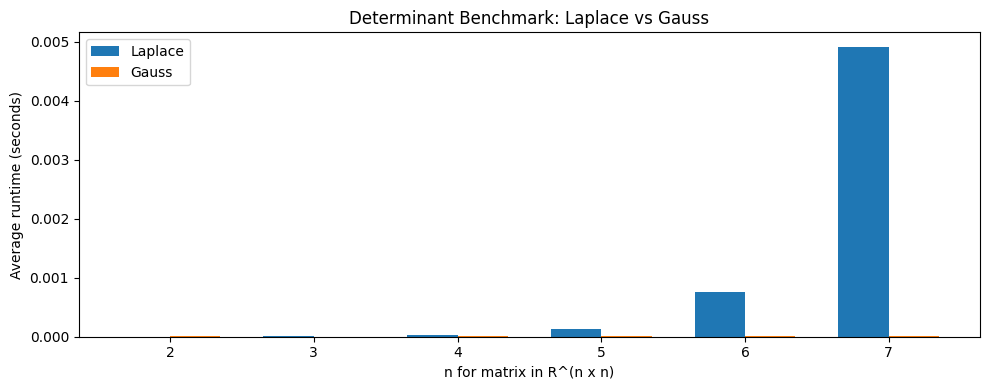

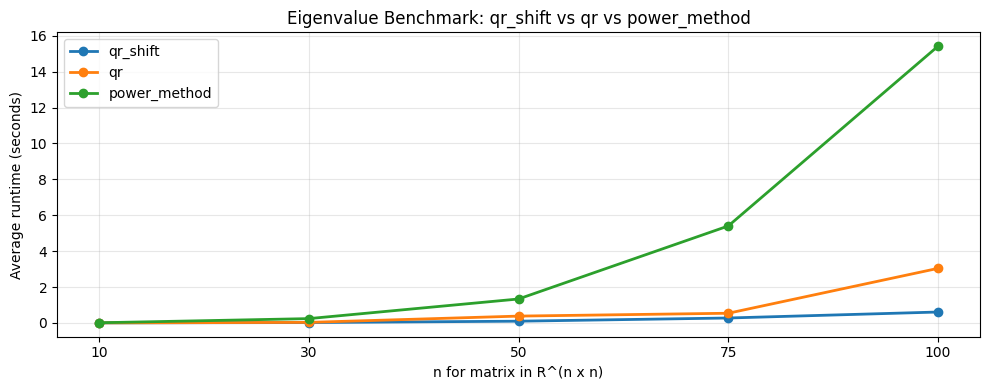

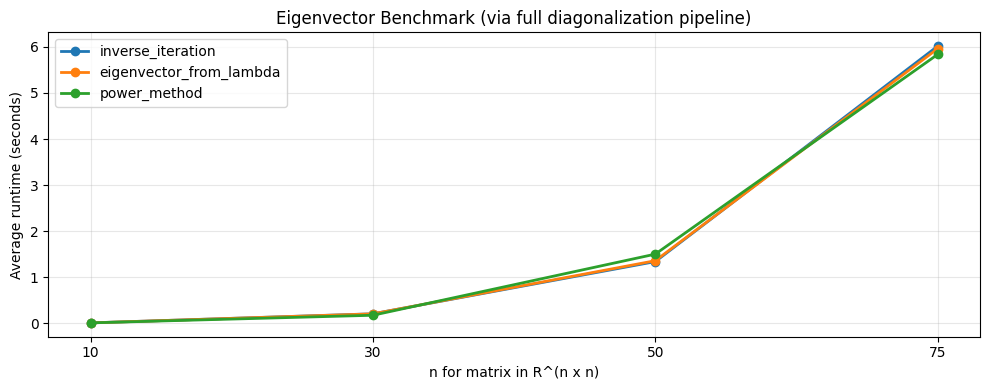

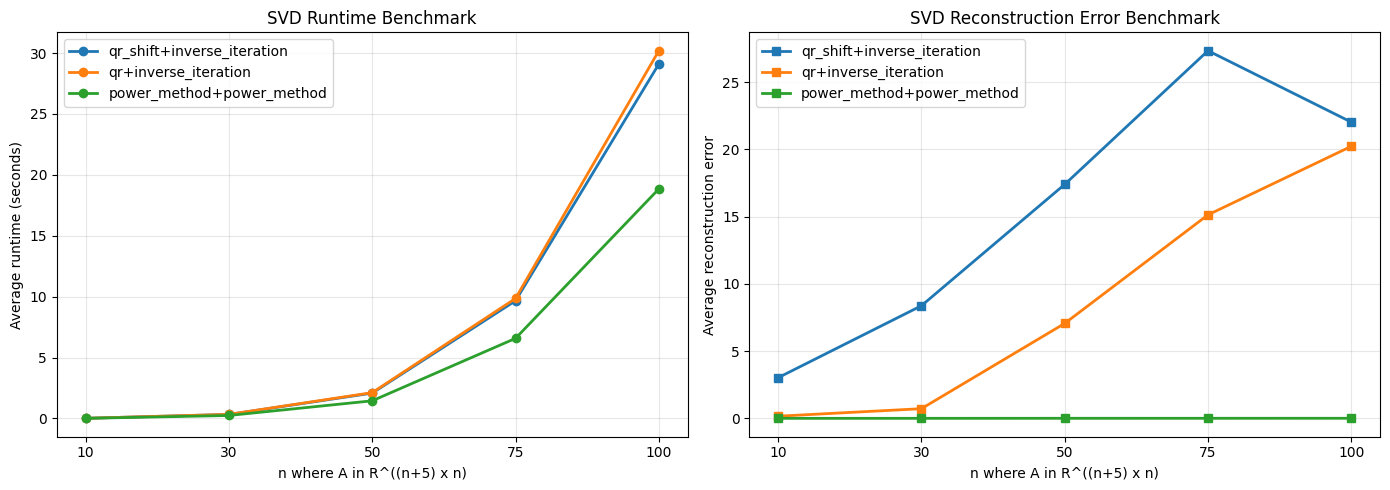

Determinant benchmark: {'sizes': [2, 3, 4, 5, 6, 7], 'laplace': [2.5529989216011018e-06, 7.363599434029311e-06, 2.7913800295209512e-05, 0.00012615999949048274, 0.0007663999997021165, 0.004915428601088933], 'gauss': [3.825000021606684e-06, 3.674800245789811e-06, 5.398199573392049e-06, 7.678399560973048e-06, 1.157139995484613e-05, 1.8961400201078504e-05]}
Eigenvalue benchmark: {'sizes': [10, 30, 50, 75, 100], 'qr_shift': [0.0012203645001136465, 0.019581302998631145, 0.09558185800051433, 0.27348132749830256, 0.6066109930015955], 'qr': [0.0012537155016616452, 0.029491059000065434, 0.3792393284984428, 0.5385054329981358, 3.038898955001059], 'power_method': [0.007563812499938649, 0.23911927650078724, 1.332721513001161, 5.400527883000905, 15.417488916002185]}
Eigenvector benchmark: {'sizes': [10, 30, 50, 75], 'inverse_iteration': [0.0056629294995218515, 0.2031613599992852, 1.3362505990007776, 6.016898984000363], 'eigenvector_from_lambda': [0.005471664499054896, 0.20142681399920548, 1.35619140

In [10]:
# Benchmark 1: Determinant methods

def benchmark_determinants(sizes=(2, 3, 4, 5, 6, 7), samples=5):
    laplace_t = []
    gauss_t = []

    for n in sizes:
        lt, gt = [], []
        for s in range(samples):
            A = generate_random_matrix(n, n, seed=100 + n * 10 + s)
            t0 = time.perf_counter(); _ = laplace_get_determinant(A); t1 = time.perf_counter()
            _ = gauss_get_determinant(A); t2 = time.perf_counter()
            lt.append(t1 - t0)
            gt.append(t2 - t1)
        laplace_t.append(float(np.mean(lt)))
        gauss_t.append(float(np.mean(gt)))

    x = np.arange(len(sizes)); w = 0.35
    plt.figure(figsize=(10, 4))
    plt.bar(x - w/2, laplace_t, width=w, label='Laplace')
    plt.bar(x + w/2, gauss_t, width=w, label='Gauss')
    plt.xticks(x, [str(n) for n in sizes])
    plt.xlabel('n for matrix in R^(n x n)')
    plt.ylabel('Average runtime (seconds)')
    plt.title('Determinant Benchmark: Laplace vs Gauss')
    plt.legend(); plt.tight_layout(); plt.show()

    return {'sizes': list(sizes), 'laplace': laplace_t, 'gauss': gauss_t}


# Helper for full eigenvalue extraction by power+deflation

def _all_eigenvalues_power(A):
    A_work = [row[:] for row in A]
    vals = []
    for _ in range(len(A)):
        lam, v = power_iteration(A_work)
        vals.append(lam)
        A_work = deflation(A_work, lam, v)
    return vals


# Benchmark 2: Eigenvalue methods

def benchmark_eigenvalue_methods(sizes=(10, 30, 50, 75, 100), samples=2):
    methods = ['qr_shift', 'qr', 'power_method']
    times = {m: [] for m in methods}

    for n in sizes:
        batch = {m: [] for m in methods}
        for s in range(samples):
            A = generate_symmetric_matrix(n, seed=200 + n * 10 + s)

            t0 = time.perf_counter(); _ = eig_qrshift(A); t1 = time.perf_counter()
            batch['qr_shift'].append(t1 - t0)

            t0 = time.perf_counter(); _ = eig_qr(A); t1 = time.perf_counter()
            batch['qr'].append(t1 - t0)

            t0 = time.perf_counter(); _ = _all_eigenvalues_power(A); t1 = time.perf_counter()
            batch['power_method'].append(t1 - t0)

        for m in methods:
            times[m].append(float(np.mean(batch[m])))

    x = np.arange(len(sizes))
    plt.figure(figsize=(10, 4))
    for m in methods:
        plt.plot(x, times[m], marker='o', linewidth=2, label=m)
    plt.xticks(x, [str(n) for n in sizes])
    plt.xlabel('n for matrix in R^(n x n)')
    plt.ylabel('Average runtime (seconds)')
    plt.title('Eigenvalue Benchmark: qr_shift vs qr vs power_method')
    plt.grid(True, alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

    return {'sizes': list(sizes), **times}


# Benchmark 3: Eigenvector pipelines (inside full diagonalization)

def benchmark_eigenvector_methods(sizes=(10, 30, 50, 75), samples=2):
    methods = ['inverse_iteration', 'eigenvector_from_lambda', 'power_method']
    times = {m: [] for m in methods}

    for n in sizes:
        batch = {m: [] for m in methods}
        for s in range(samples):
            A = generate_symmetric_matrix(n, seed=300 + n * 10 + s)

            t0 = time.perf_counter()
            _ = diagonalize(A, eigenvalue_method='qr_shift', eigenvector_method='inverse_iteration')
            t1 = time.perf_counter(); batch['inverse_iteration'].append(t1 - t0)

            t0 = time.perf_counter()
            _ = diagonalize(A, eigenvalue_method='qr_shift', eigenvector_method='eigenvector_from_lambda')
            t1 = time.perf_counter(); batch['eigenvector_from_lambda'].append(t1 - t0)

            t0 = time.perf_counter()
            _ = diagonalize(A, eigenvalue_method='power_method', eigenvector_method='power_method')
            t1 = time.perf_counter(); batch['power_method'].append(t1 - t0)

        for m in methods:
            times[m].append(float(np.mean(batch[m])))

    x = np.arange(len(sizes))
    plt.figure(figsize=(10, 4))
    for m in methods:
        plt.plot(x, times[m], marker='o', linewidth=2, label=m)
    plt.xticks(x, [str(n) for n in sizes])
    plt.xlabel('n for matrix in R^(n x n)')
    plt.ylabel('Average runtime (seconds)')
    plt.title('Eigenvector Benchmark (via full diagonalization pipeline)')
    plt.grid(True, alpha=0.3)
    plt.legend(); plt.tight_layout(); plt.show()

    return {'sizes': list(sizes), **times}


# Benchmark 4: SVD method combinations

def benchmark_svd_methods(sizes=(10, 30, 50, 75, 100), samples=2):
    combos = [
        ('qr_shift', 'inverse_iteration'),
        ('qr', 'inverse_iteration'),
        ('power_method', 'power_method'),
    ]
    labels = [f"{a}+{b}" for a, b in combos]

    times = {lb: [] for lb in labels}
    errors = {lb: [] for lb in labels}

    for n in sizes:
        m = n + 5
        t_batch = {lb: [] for lb in labels}
        e_batch = {lb: [] for lb in labels}

        for s in range(samples):
            A = generate_random_matrix(m, n, seed=400 + n * 10 + s)
            for (ev, evec), lb in zip(combos, labels):
                t0 = time.perf_counter()
                U, S, V = svd_decomposition(A, eigenvalue_method=ev, eigenvector_method=evec)
                t1 = time.perf_counter()
                t_batch[lb].append(t1 - t0)
                e_batch[lb].append(reconstruction_error(A, U, S, V))

        for lb in labels:
            times[lb].append(float(np.mean(t_batch[lb])))
            errors[lb].append(float(np.mean(e_batch[lb])))

    x = np.arange(len(sizes))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for lb in labels:
        axes[0].plot(x, times[lb], marker='o', linewidth=2, label=lb)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([str(n) for n in sizes])
    axes[0].set_xlabel('n where A in R^((n+5) x n)')
    axes[0].set_ylabel('Average runtime (seconds)')
    axes[0].set_title('SVD Runtime Benchmark')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    for lb in labels:
        axes[1].plot(x, errors[lb], marker='s', linewidth=2, label=lb)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([str(n) for n in sizes])
    axes[1].set_xlabel('n where A in R^((n+5) x n)')
    axes[1].set_ylabel('Average reconstruction error')
    axes[1].set_title('SVD Reconstruction Error Benchmark')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout(); plt.show()

    return {'sizes': list(sizes), 'times': times, 'errors': errors}


det_bench = benchmark_determinants()
eigval_bench = benchmark_eigenvalue_methods()
eigvec_bench = benchmark_eigenvector_methods()
svd_bench = benchmark_svd_methods()

print('Determinant benchmark:', det_bench)
print('Eigenvalue benchmark:', eigval_bench)
print('Eigenvector benchmark:', eigvec_bench)
print('SVD benchmark:', svd_bench)
